In [61]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from datetime import timedelta, datetime, date

In [62]:
#Custom Yahoo Finance Get Data Fn
def GetYahooFinanceData(ticker, start, end):
    formatDate = "%Y-%m-%d"
    end = datetime.strptime(end, formatDate)
    end = end + timedelta(days = 1)
    end = end.strftime(formatDate)
    #this is to make sure the end date is included in the df

    df = yf.download(ticker, start, end)
    return df

stock_data = GetYahooFinanceData('BTC-USD','2022-01-01','2025-01-01')
stock_data

C:\Users\ashvi\AppData\Local\Temp\ipykernel_21100\3613052473.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2022-01-01,47686.812500,47827.312500,46288.484375,46311.746094,24582667004
2022-01-02,47345.218750,47881.406250,46856.937500,47680.925781,27951569547
2022-01-03,46458.117188,47510.726562,45835.964844,47343.542969,33071628362
2022-01-04,45897.574219,47406.546875,45752.464844,46458.851562,42494677905
2022-01-05,43569.003906,46929.046875,42798.222656,45899.359375,36851084859
...,...,...,...,...,...
2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,24107436185
2024-12-29,93530.226562,95174.875000,92881.789062,95174.054688,29635885267


In [63]:
#Calculate EMA12, EMA128, and EMA200 -> different lengths short to long term

stock_data['EMA12'] = stock_data['Close'].ewm(span=12, min_periods=0, adjust=False).mean()
stock_data['EMA50'] = stock_data['Close'].ewm(span=50, min_periods=0, adjust=False).mean()
stock_data['EMA128'] = stock_data['Close'].ewm(span=128, min_periods=0, adjust=False).mean()
stock_data['EMA200'] = stock_data['Close'].ewm(span=200, min_periods=0, adjust=False).mean()
#ewm is a pandas fn that calc the exponential weighted moving avg for a df (dataframe)
stock_data

Price,Close,High,Low,Open,Volume,EMA12,EMA50,EMA128,EMA200
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,,
Date,,,,,,,,,
2022-01-01,47686.812500,47827.312500,46288.484375,46311.746094,24582667004,47686.812500,47686.812500,47686.812500,47686.812500
2022-01-02,47345.218750,47881.406250,46856.937500,47680.925781,27951569547,47634.259615,47673.416667,47681.516473,47683.413557
2022-01-03,46458.117188,47510.726562,45835.964844,47343.542969,33071628362,47453.314626,47625.757864,47662.549042,47671.221554
2022-01-04,45897.574219,47406.546875,45752.464844,46458.851562,42494677905,47213.969948,47557.985956,47635.185091,47653.573321
2022-01-05,43569.003906,46929.046875,42798.222656,45899.359375,36851084859,46653.205942,47401.555287,47572.143523,47612.930840
...,...,...,...,...,...,...,...,...,...
2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,24107436185,97201.826435,93221.171722,81706.525936,75643.602991
2024-12-29,93530.226562,95174.875000,92881.789062,95174.054688,29635885267,96636.964916,93233.291519,81889.839124,75821.579345


In [64]:
# Buy and Sell Signal Logic

stock_data['Buy_Signal'] = 0
stock_data['Sell_Signal'] = 0

for i in range(1, len(stock_data)):
    # golden cross -> buy signal [ema12 crosses above ema128]
    if (stock_data['EMA50'].iloc[i] > stock_data['EMA200'].iloc[i]) and (stock_data['EMA50'].iloc[i-1] <= stock_data['EMA200'].iloc[i-1]):
        stock_data.loc[stock_data.index[i], 'Buy_Signal'] = 1
    # death cross -> sell signal [ema12 crosses below ema128]
    elif (stock_data['EMA50'].iloc[i] < stock_data['EMA200'].iloc[i]) and (stock_data['EMA50'].iloc[i-1] >= stock_data['EMA200'].iloc[i-1]):
        stock_data.loc[stock_data.index[i], 'Sell_Signal'] = -1

stock_data

Price,Close,High,Low,Open,Volume,EMA12,EMA50,EMA128,EMA200,Buy_Signal,Sell_Signal
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,,,,
Date,,,,,,,,,,,
2022-01-01,47686.812500,47827.312500,46288.484375,46311.746094,24582667004,47686.812500,47686.812500,47686.812500,47686.812500,0,0
2022-01-02,47345.218750,47881.406250,46856.937500,47680.925781,27951569547,47634.259615,47673.416667,47681.516473,47683.413557,0,-1
2022-01-03,46458.117188,47510.726562,45835.964844,47343.542969,33071628362,47453.314626,47625.757864,47662.549042,47671.221554,0,0
2022-01-04,45897.574219,47406.546875,45752.464844,46458.851562,42494677905,47213.969948,47557.985956,47635.185091,47653.573321,0,0
2022-01-05,43569.003906,46929.046875,42798.222656,45899.359375,36851084859,46653.205942,47401.555287,47572.143523,47612.930840,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,24107436185,97201.826435,93221.171722,81706.525936,75643.602991,0,0
2024-12-29,93530.226562,95174.875000,92881.789062,95174.054688,29635885267,96636.964916,93233.291519,81889.839124,75821.579345,0,0


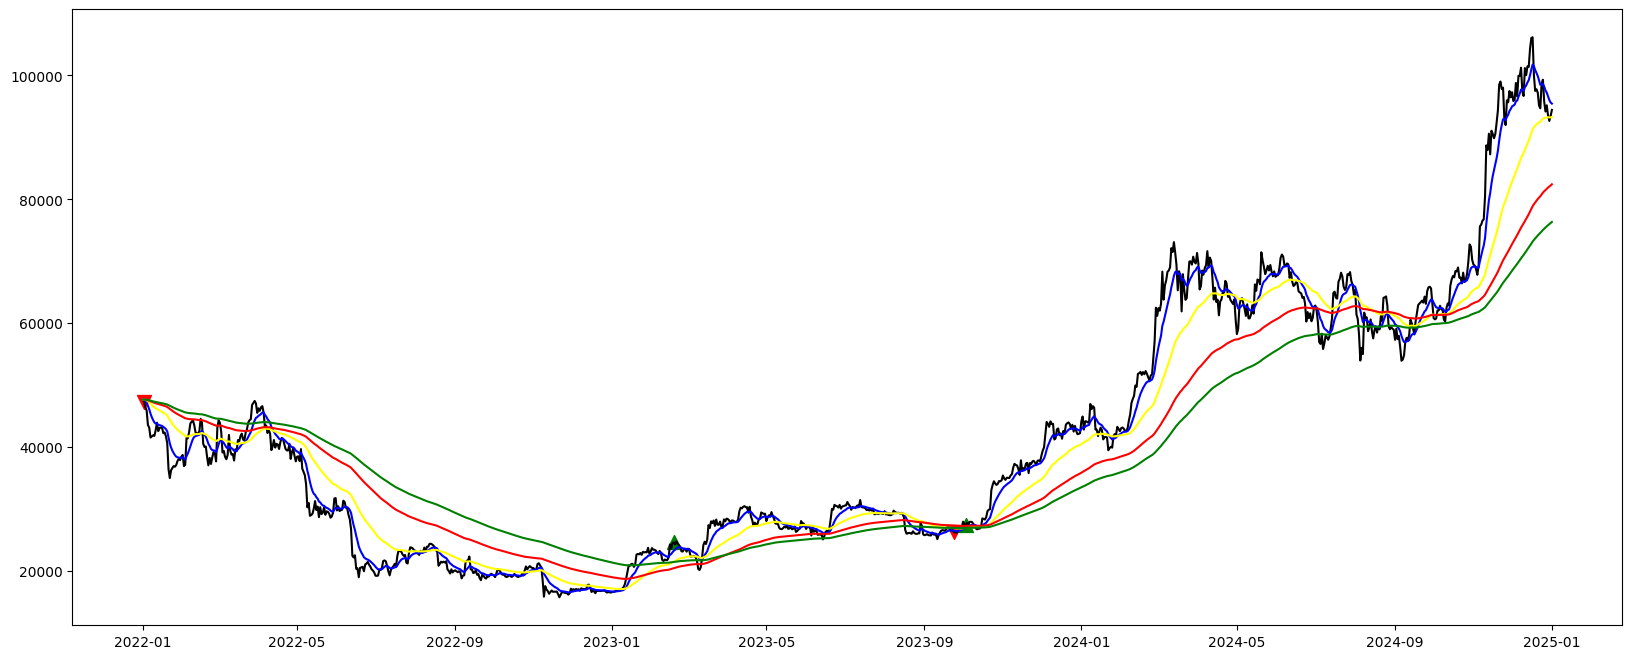

In [ ]:
#Plot

plt.figure(figsize=(20,8))

plt.plot(stock_data.index, stock_data['Close'], label='Close Price', color = 'black')
plt.plot(stock_data.index, stock_data['EMA12'], label='EMA12', color = 'blue')
plt.plot(stock_data.index, stock_data['EMA50'], label='EMA50', color = 'yellow')
plt.plot(stock_data.index, stock_data['EMA128'], label='EMA128', color = 'red')
plt.plot(stock_data.index, stock_data['EMA200'], label='EMA200', color = 'green')

buy_signals = stock_data[stock_data['Buy_Signal'] == 1]
plt.scatter(buy_signals.index, buy_signals['Close'], marker="^", label = "Buy Signal", color = 'green', s = 100)

sell_signals = stock_data[stock_data['Sell_Signal'] == -1]
plt.scatter(sell_signals.index, sell_signals['Close'], marker="v", label = "Sell Signal", color = 'red', s = 100)



In [134]:
#Backtesting -> trading on historical data to assess profitability and risk

transaction_cost = 5

# Create arrays for equity tracking
algo_equity = []
bnh_equity = []

initial_capital = 100000
position = 0
capital = initial_capital
bought_and_held_capital = capital
bought_and_held_shares = (capital - transaction_cost) / stock_data['Close'].iloc[0]

for i in range(len(stock_data)):
    if stock_data['Buy_Signal'].iloc[i] == 1:
        shares_to_buy = capital // stock_data['Close'].iloc[i]
        position += shares_to_buy
        capital -= shares_to_buy * stock_data['Close'].iloc[i] + transaction_cost
    elif stock_data['Sell_Signal'].iloc[i] == -1:
        capital += position * stock_data['Close'].iloc[i] - transaction_cost
        position = 0
    
    bought_and_held_capital = bought_and_held_shares * stock_data["Close"].iloc[i]

    # Append to arrays instead of assigning to DataFrame
    algo_equity.append((capital + position * stock_data["Close"].iloc[i]).item())
    bnh_equity.append((bought_and_held_shares * stock_data["Close"].iloc[i]).item())

# Add to stock_data as new columns
stock_data['Algo_Equity'] = algo_equity
stock_data['BNH_Equity'] = bnh_equity

algorithm_final_value = capital + position * stock_data['Close'].iloc[-1]
bought_and_held_final_value = bought_and_held_capital

algorithm_final_percent = (algorithm_final_value - initial_capital)/initial_capital
bought_and_held_final_percent = (bought_and_held_final_value - initial_capital) / initial_capital

print("Algorithm final value: $", round(algorithm_final_value.item(), 2), "%: ", round(algorithm_final_percent.item()*100, 1))
print("Bought and held final value: $", round(bought_and_held_final_value.item(), 2), "%: ", round(bought_and_held_final_percent.item()*100, 1))
stock_data

Algorithm final value: $ 307411.53 %:  207.4
Bought and held final value: $ 197989.83 %:  98.0


Price,Close,High,Low,Open,Volume,EMA12,EMA50,EMA128,EMA200,Buy_Signal,Sell_Signal,Algo_Equity,BNH_Equity
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,,,,,,
Date,,,,,,,,,,,,,
2022-01-01,47686.812500,47827.312500,46288.484375,46311.746094,24582667004,47686.812500,47686.812500,47686.812500,47686.812500,0,0,100000.000000,99995.000000
2022-01-02,47345.218750,47881.406250,46856.937500,47680.925781,27951569547,47634.259615,47673.416667,47681.516473,47683.413557,0,-1,99995.000000,99278.708320
2022-01-03,46458.117188,47510.726562,45835.964844,47343.542969,33071628362,47453.314626,47625.757864,47662.549042,47671.221554,0,0,99995.000000,97418.535327
2022-01-04,45897.574219,47406.546875,45752.464844,46458.851562,42494677905,47213.969948,47557.985956,47635.185091,47653.573321,0,0,99995.000000,96243.126630
2022-01-05,43569.003906,46929.046875,42798.222656,45899.359375,36851084859,46653.205942,47401.555287,47572.143523,47612.930840,0,0,99995.000000,91360.322009
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,24107436185,97201.826435,93221.171722,81706.525936,75643.602991,0,0,309644.048828,199550.287600
2024-12-29,93530.226562,95174.875000,92881.789062,95174.054688,29635885267,96636.964916,93233.291519,81889.839124,75821.579345,0,0,304742.939453,196124.557604


c:\Users\ashvi\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
c:\Users\ashvi\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1355: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


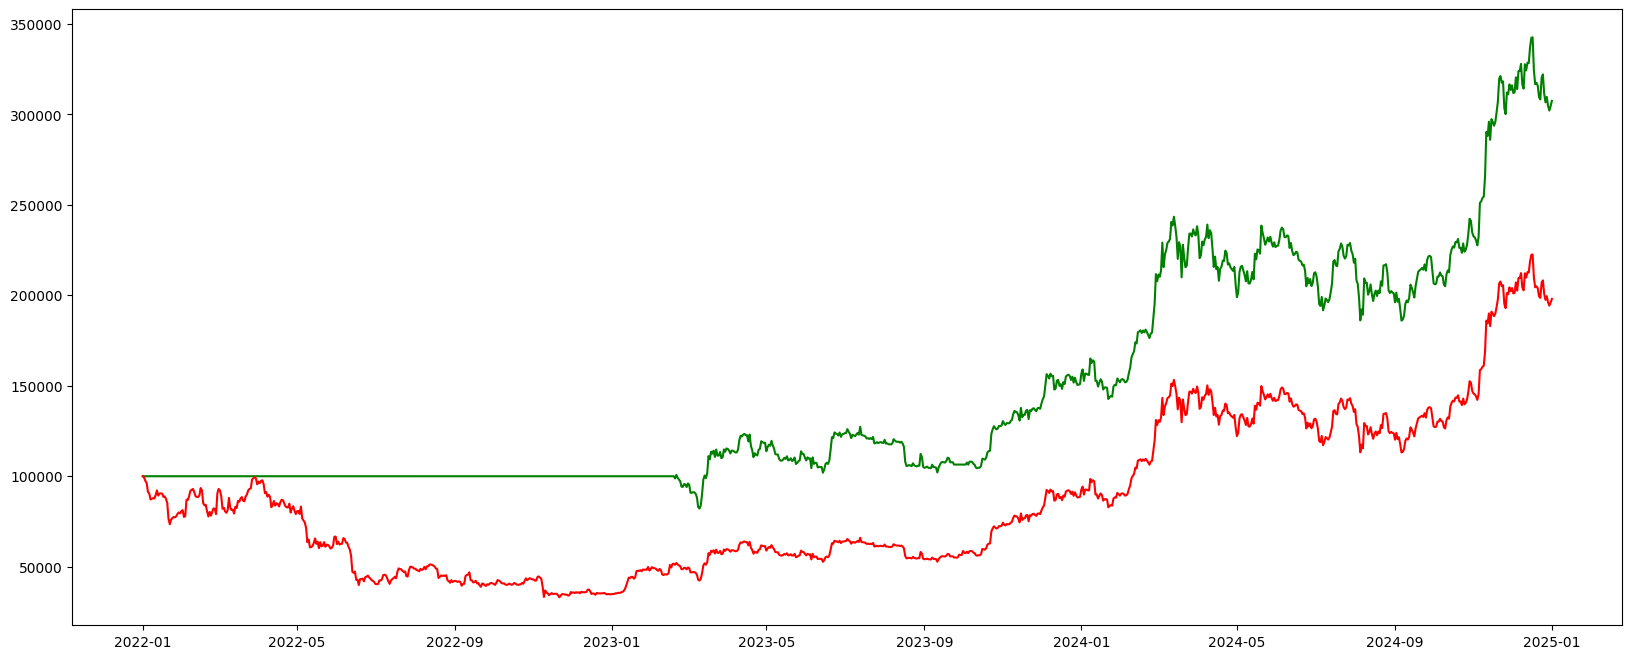

In [129]:
#Equity Curve Plot

plt.figure(figsize=(20,8))

plt.plot(stock_data.index, stock_data['Algo_Equity'], label = 'Algorithm Equity', color = 'green')
plt.plot(stock_data.index, stock_data['BNH_Equity'], label = 'Bought and Hold Equity', color = 'red')